In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from treasury_ml_utils.snowflake_utils import SnowflakeConnector

snowflake_client = SnowflakeConnector("joshua.choy@transferwise.com")

10.8.0


In [24]:
# CNY 2026: 17 Jan – 2 Feb (golden week).
# Fetch a wider window (1 Jan – 28 Feb) for context — so we can see pre/during/post holiday.

cny_df = snowflake_client.fetch(("""
    SELECT *
    FROM rpt_treasury.int_liquidity__hourly_excess
    WHERE (LOWER(account_name) LIKE '%alipay%' OR LOWER(account_name) LIKE '%wechat%')
      AND ccy = 'CNY'
      AND timestamp_hour BETWEEN '2026-01-01' AND '2026-02-28'
    ORDER BY account_name, timestamp_hour ASC
"""))

print(f"Shape: {cny_df.shape}")
print(f"Accounts: {cny_df['account_name'].unique().tolist()}")
cny_df.head()

Shape: (2786, 13)
Accounts: ['Alipay CNY', 'WeChat CNY']


,_surrogate_key,ccy,account_id,account_name,account_type,timestamp_hour,timestamp_month,hour_gbp_excess,duration_hours,wacc,_airflow_run_id,_sdc_batched_at,_sdc_loaded_at
0,871934a7e94c6137fe1ac117c641329e,CNY,1174,Alipay CNY,PAYOUT,2026-01-01 00:00:00,2026-01-01,6.359265e+06,22.0,0.1005,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
1,4c0f36e0d600cb47217f8e0b91f03cd2,CNY,1174,Alipay CNY,PAYOUT,2026-01-01 01:00:00,2026-01-01,6.359265e+06,22.0,0.1005,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
2,9435284d19b490cc3edea8f1b77e564e,CNY,1174,Alipay CNY,PAYOUT,2026-01-01 02:00:00,2026-01-01,6.359265e+06,22.0,0.1005,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
3,11eae015b73f89c8d13fd519429ba25e,CNY,1174,Alipay CNY,PAYOUT,2026-01-01 03:00:00,2026-01-01,6.359265e+06,22.0,0.1005,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
4,79c45422a415035c1748a490cc9e1e55,CNY,1174,Alipay CNY,PAYOUT,2026-01-01 04:00:00,2026-01-01,6.359265e+06,22.0,0.1005,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00


In [25]:
# CNY excess in CNY-denominated accounts — 26 January 2026
# First: inspect available columns to confirm the CNY excess field name

jan26_cny = snowflake_client.fetch(("""
    SELECT *
    FROM rpt_treasury.int_liquidity__hourly_excess
    WHERE ccy = 'CNY'
      AND timestamp_hour BETWEEN '2026-01-26 00:00:00' AND '2026-01-26 23:59:59'
    ORDER BY account_name, timestamp_hour ASC
"""))

print(f"Shape: {jan26_cny.shape}")
print(f"Columns: {jan26_cny.columns.tolist()}")
print(f"Accounts: {jan26_cny['account_name'].unique().tolist()}")
jan26_cny.head(20)

Shape: (192, 13)
Columns: ['_surrogate_key', 'ccy', 'account_id', 'account_name', 'account_type', 'timestamp_hour', 'timestamp_month', 'hour_gbp_excess', 'duration_hours', 'wacc', '_airflow_run_id', '_sdc_batched_at', '_sdc_loaded_at']
Accounts: ['Alipay CNY', 'Bank of Shanghai (CNY)', 'Barclays BARX CNY', 'DBS HK Multi Currency Account (CNY)', 'JPM WPL SWIFT Receive CNY', 'JPMorgan TW LTD HK (CNH)', 'Lakala (CNY)', 'WeChat CNY']


,_surrogate_key,ccy,account_id,account_name,account_type,timestamp_hour,timestamp_month,hour_gbp_excess,duration_hours,wacc,_airflow_run_id,_sdc_batched_at,_sdc_loaded_at
0,2d422d92ccbba34c1f3b55110e6c5fbb,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 00:00:00,2026-01-01,100.458555,71.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
1,041e5f2a7a7c7581d553d71a82a608b1,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 01:00:00,2026-01-01,100.458555,71.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
2,a20fcf874719cd830d503ecdfd355b17,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 02:00:00,2026-01-01,50.524997,1.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
3,acb045f9f8507dc0f8c11be2448c0bec,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 03:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
4,0a39c6f4c53aa2eab3ce55d49fa407af,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 04:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
5,b7fa793a0ba93609463ef745819413c0,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 05:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
6,92530f3238cebe10be5ea99477b5cfa4,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 06:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
7,17b0da4024ce7f6646fbbeb2dbaa135f,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 07:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
8,7c6f1e20b8e4531ad585df2c2eef34a8,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 08:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00
9,686141848de9e6c105e77008da66adf3,CNY,1174,Alipay CNY,PAYOUT,2026-01-26 09:00:00,2026-01-01,19.566682,25.0,0.0725,scheduled__2026-03-16T00:00:00+00:00,2026-03-16,2026-03-17 01:32:08.493000+00:00


In [26]:
# CNY excess in CNY-denominated accounts — 26 January 2026 (aggregated)
# Assumes column is named 'hour_cny_excess' — update if schema differs

jan26_cny['timestamp_hour'] = pd.to_datetime(jan26_cny['timestamp_hour'])

# Identify the CNY excess column automatically
cny_excess_col = next(
    (c for c in jan26_cny.columns if 'cny' in c.lower() and 'excess' in c.lower()),
    None
)
if cny_excess_col is None:
    # Fallback: any column with 'excess'
    cny_excess_col = next((c for c in jan26_cny.columns if 'excess' in c.lower()), None)

print(f"Using column: {cny_excess_col}")

# Total CNY excess per account over the full day
jan26_summary = (
    jan26_cny
    .groupby('account_name')[cny_excess_col]
    .sum()
    .reset_index()
    .rename(columns={cny_excess_col: 'total_cny_excess'})
    .sort_values('total_cny_excess', ascending=False)
)

print("\nCNY Excess by Account — 26 January 2026:")
print(jan26_summary.to_string(index=False))
jan26_summary

Using column: hour_gbp_excess

CNY Excess by Account — 26 January 2026:
                       account_name  total_cny_excess
                       Lakala (CNY)      1.001348e+08
          JPM WPL SWIFT Receive CNY      1.809769e+07
           JPMorgan TW LTD HK (CNH)      3.799160e+06
DBS HK Multi Currency Account (CNY)      5.802313e+05
                         WeChat CNY      2.579312e+05
                  Barclays BARX CNY      5.293412e+04
                         Alipay CNY      6.623424e+02
             Bank of Shanghai (CNY)      0.000000e+00


,account_name,total_cny_excess
6,Lakala (CNY),1.001348e+08
4,JPM WPL SWIFT Receive CNY,1.809769e+07
5,JPMorgan TW LTD HK (CNH),3.799160e+06
3,DBS HK Multi Currency Account (CNY),5.802313e+05
7,WeChat CNY,2.579312e+05
2,Barclays BARX CNY,5.293412e+04
0,Alipay CNY,6.623424e+02
1,Bank of Shanghai (CNY),0.000000e+00


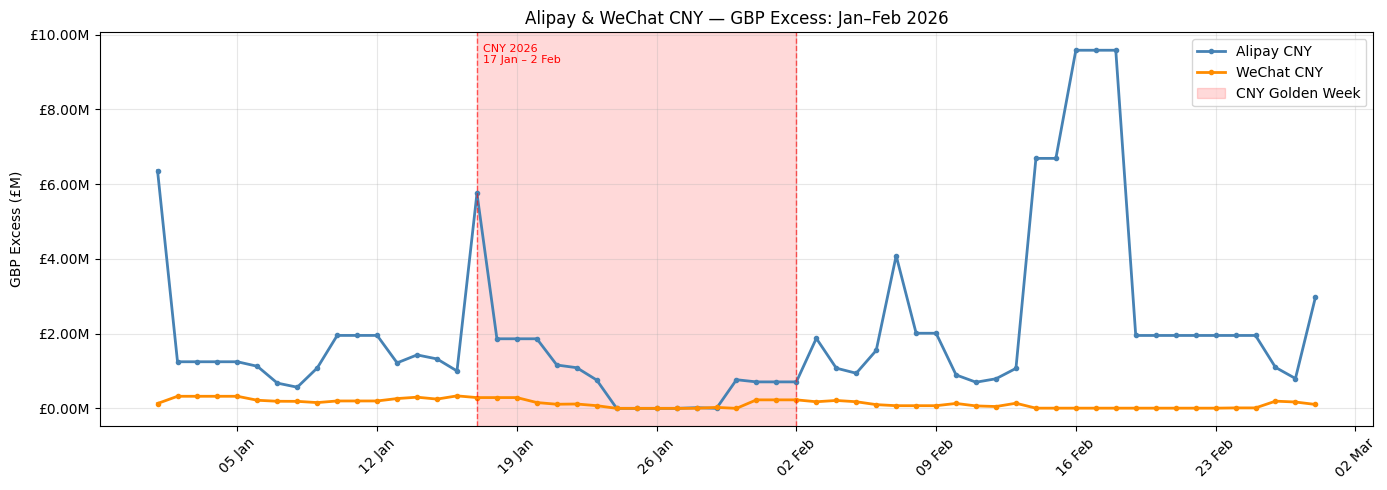

In [27]:
import matplotlib.patches as mpatches
import matplotlib.dates as mdates

cny_df['timestamp_hour'] = pd.to_datetime(cny_df['timestamp_hour'])
cny_df['date'] = cny_df['timestamp_hour'].dt.date

# Deduplicate to one row per account per day
daily_cny = (
    cny_df
    .groupby(['account_name', 'date'])
    .agg(hour_gbp_excess=('hour_gbp_excess', 'first'))
    .reset_index()
)
daily_cny['date'] = pd.to_datetime(daily_cny['date'])

accounts = daily_cny['account_name'].unique()
colors = {'alipay': 'steelblue', 'wechat': 'darkorange'}

fig, ax = plt.subplots(figsize=(14, 5))

for name in accounts:
    sub = daily_cny[daily_cny['account_name'] == name]
    key = 'alipay' if 'alipay' in name.lower() else 'wechat'
    ax.plot(sub['date'], sub['hour_gbp_excess'] / 1e6, lw=2, marker='o', ms=3,
            color=colors[key], label=name)

# Shade CNY golden week: 17 Jan – 2 Feb 2026
cny_start = pd.Timestamp('2026-01-17')
cny_end   = pd.Timestamp('2026-02-02')
ax.axvspan(cny_start, cny_end, alpha=0.15, color='red', label='CNY Golden Week')
ax.axvline(cny_start, color='red', lw=1, linestyle='--', alpha=0.6)
ax.axvline(cny_end,   color='red', lw=1, linestyle='--', alpha=0.6)
ax.text(cny_start + pd.Timedelta(days=0.3), ax.get_ylim()[1] * 0.97,
        'CNY 2026\n17 Jan – 2 Feb', fontsize=8, color='red', va='top')

ax.set_ylabel('GBP Excess (£M)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.2f}M'))
ax.set_title('Alipay & WeChat CNY — GBP Excess: Jan–Feb 2026')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0))
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

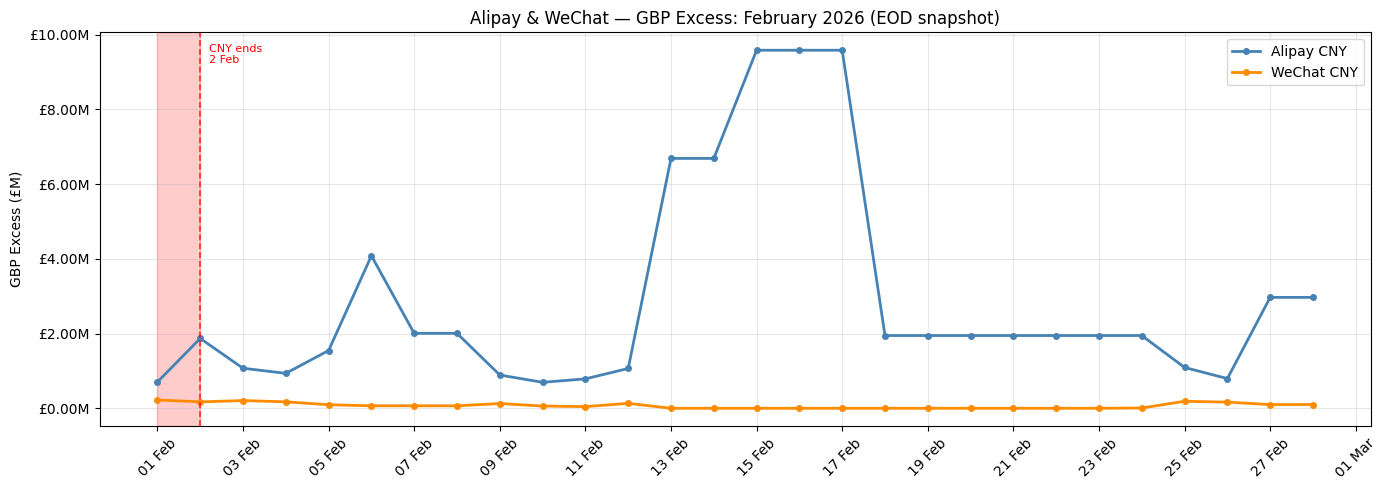

In [28]:
import matplotlib.dates as mdates

cny_df['timestamp_hour'] = pd.to_datetime(cny_df['timestamp_hour'])
cny_df['date'] = cny_df['timestamp_hour'].dt.date

# Filter to February only
feb_df = cny_df[
    (cny_df['timestamp_hour'] >= '2026-02-01') &
    (cny_df['timestamp_hour'] < '2026-03-01')
]

# End-of-day snapshot: take the last hourly reading per account per day
daily_feb = (
    feb_df
    .sort_values('timestamp_hour')
    .groupby(['account_name', 'date'])['hour_gbp_excess']
    .last()
    .reset_index()
)
daily_feb['date'] = pd.to_datetime(daily_feb['date'])

accounts = daily_feb['account_name'].unique()
colors = {'alipay': 'steelblue', 'wechat': 'darkorange'}

fig, ax = plt.subplots(figsize=(14, 5))

for name in accounts:
    sub = daily_feb[daily_feb['account_name'] == name]
    key = 'alipay' if 'alipay' in name.lower() else 'wechat'
    ax.plot(sub['date'], sub['hour_gbp_excess'] / 1e6, lw=2, marker='o', ms=4,
            color=colors[key], label=name)

# CNY golden week ends 2 Feb — shade the tail end that falls in February
cny_end = pd.Timestamp('2026-02-02')
ax.axvspan(pd.Timestamp('2026-02-01'), cny_end, alpha=0.2, color='red')
ax.axvline(cny_end, color='red', lw=1.2, linestyle='--', alpha=0.8)
ax.text(cny_end + pd.Timedelta(days=0.2), ax.get_ylim()[1] * 0.97,
        'CNY ends\n2 Feb', fontsize=8, color='red', va='top')

ax.set_ylabel('GBP Excess (£M)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'£{x:.2f}M'))
ax.set_title('Alipay & WeChat — GBP Excess: February 2026 (EOD snapshot)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
ax.legend()
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()